In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
import umap

/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/schmiedc/miniconda3/envs/vspaint/lib/python3.9/site-packag

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# UMAP 

Settings:

n_neighbors = 30

min_dist = 0.1

In [4]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features);

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)

    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))
    fig.suptitle(title, fontsize=18)
    
    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_inactive',
        palette = ["lightgray", "navy"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_' + cell_type + '_Toxic',
        palette = ["lightgray", "purple"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_tubulin',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0, 2]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_DMSO',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Nocodazole',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Metadata_Tetrandrine',
        palette = marker_color,
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[1, 2]
    )
    
    plt.savefig(filename)  

# Load and process annotations

In [5]:
annotation_compounds = pd.read_csv(annot_path + "pd_export_04_2022_2464_compounds_standardized.csv")
annotation_compounds.columns = annotation_compounds.columns.str.replace(' ', '_')
annotation_compounds = annotation_compounds.add_prefix('Metadata_')

In [6]:
annotation_targets = pd.read_csv(annot_path + 'pd_export_04_2022_2464_targets_standardized.csv')
annotation_targets.columns = annotation_targets.columns.str.replace(' ', '_')
annotation_targets = annotation_targets.add_prefix('Metadata_')
annotation_targets.shape

(29915, 31)

In [7]:
id_file = pd.read_csv(annot_path + "2024-08-02_EOS_pdid.csv")
id_file.shape

(2464, 2)

In [8]:
annotation_tubulin = pd.read_csv(annot_path + "2024-08-02_Tubulin.csv")
annotation_tubulin.shape

(2464, 2)

In [9]:
# get EUOS number 
annotation_compounds = pd.merge(annotation_compounds,
                     annotation_tubulin,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

In [10]:
# get EUOS number 
annotation_compounds_2 = pd.merge(annotation_compounds,
                     id_file,
                     on = ["Metadata_pdid"],
                     how = "left",
                     indicator = False)

# HepG2

## Normalized data

In [11]:
# Load normalized data
file_HepG2_type = '/*[0-9]_' + 'FMP_HepG2_norm.csv'
files_HepG2 = glob.glob(input_path + file_HepG2_type)

### gets latest file
max_file_HepG2 = max(files_HepG2, key=os.path.getctime)

### load file
data_HepG2_Norm = pd.read_csv(max_file_HepG2)
data_HepG2_Norm.shape

(10697, 2984)

In [12]:
# HepG2 feature reduction
print("Feature reduction with correlation threshold 0.9 and Outlier threshold 100")
HepG2_Reduced_Carsten_100_Mod = UTIL.feature_reduction(data_HepG2_Norm, 
                                         variance_freq_cut=0.1, 
                                         variance_unique_cut=0.1, 
                                         outlier_cutoff=100, 
                                         corr_threshold = 0.9, 
                                         print_stats = True)

Feature reduction with correlation threshold 0.9 and Outlier threshold 100
| Category           |   Original Features |   Variance Threshold |   % Variance |   Outlier Threshold |   % Outlier |   Correlation Threshold |   % Correlation |
|:-------------------|--------------------:|---------------------:|-------------:|--------------------:|------------:|------------------------:|----------------:|
| Total Features     |                2977 |                 2811 |         94.4 |                2177 |        73.1 |                     654 |            22   |
| Intensity          |                 180 |                  180 |        100   |                 149 |        82.8 |                      44 |            24.4 |
| Correlation        |                 180 |                  120 |         66.7 |                  99 |        55   |                      65 |            36.1 |
| AreaShape          |                 162 |                  154 |         95.1 |                 139 |      

## Remove non reproducible compounds

In [13]:
# data_HepG2_Norm = pd.read_csv(input_path + "2023-04-11_Bioactives_HepG2_norm.csv")
file_HepG2_nonreplicating_type = '/*[0-9]_' + 'FMP_HepG2_non-replicating.csv'
files_HepG2_nonreplicating = glob.glob(input_path + file_HepG2_nonreplicating_type)

### gets latest file
max_files_HepG2_nonreplicating = max(files_HepG2_nonreplicating, key=os.path.getctime)

### load file
data_HepG2_nonreplicating = pd.read_csv(max_files_HepG2_nonreplicating)
data_HepG2_nonreplicating.shape

(72, 1)

In [14]:
FMP_HepG2_Data_replicating = HepG2_Reduced_Carsten_100_Mod.loc[~HepG2_Reduced_Carsten_100_Mod["Metadata_EOS"].isin(data_HepG2_nonreplicating["Metadata_EOS"])].copy()
FMP_HepG2_Data_replicating.shape

(10409, 661)

## Get toxic compounds

In [15]:
# data_U2OS_Median = pd.read_csv(input_path + "2023-04-11_Bioactives_U2OS_norm_reduced_filtered_median.csv")
file_HepG2_tox_type = '/*[0-9]_' + 'FMP_HepG2_toxic_all.csv'
files_HepG2_tox = glob.glob(input_path + file_HepG2_tox_type)

### gets latest file
max_file_HepG2_tox = max(files_HepG2_tox, key=os.path.getctime)

### load file
data_HepG2_tox = pd.read_csv(max_file_HepG2_tox)
data_HepG2_tox.shape

(103, 1)

In [16]:
data_HepG2_tox_annot = pd.merge(data_HepG2_tox,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [17]:
annotation_compounds_2['Metadata_HepG2_Toxic'] = annotation_compounds_2['Metadata_pdid'].isin(data_HepG2_tox_annot['Metadata_pdid'])

## Get low active compounds

In [18]:
file_HepG2_inactive_type = '/*[0-9]_' + 'FMP_HepG2_low-active.csv'
files_HepG2_inactive = glob.glob(input_path + file_HepG2_inactive_type)

### gets latest file
max_file_HepG2_inactive = max(files_HepG2_inactive, key=os.path.getctime)

### load file
data_HepG2_inactive = pd.read_csv(max_file_HepG2_inactive)
data_HepG2_inactive.shape

(1503, 1)

In [19]:
data_HepG2_inactive_annot = pd.merge(data_HepG2_inactive,
                               id_file,
                               on = ["Metadata_EOS"],
                               how = "left",
                               indicator = True)

In [20]:
annotation_compounds_2['Metadata_HepG2_inactive'] = annotation_compounds_2['Metadata_pdid'].isin(data_HepG2_inactive_annot['Metadata_pdid'])

## Process for visualization

In [21]:
## gets feature vector
Features_HepG2_Norm_Reduced = UTIL.get_feature_vector(FMP_HepG2_Data_replicating)

Features_HepG2_Norm_Reduced_Median = pycytominer.consensus(
        profiles = FMP_HepG2_Data_replicating, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_HepG2_Norm_Reduced, # (str, list) – The features to collapse, defaults to “infer”
)

In [22]:
HepG2_Norm_Reduced_Median_annot = pd.merge(Features_HepG2_Norm_Reduced_Median,
                                              id_file,
                                              how = 'left',
                                              on=['Metadata_EOS'])

In [23]:
HepG2_Norm_Reduced_Median_annot2 = pd.merge(HepG2_Norm_Reduced_Median_annot,
                                              annotation_compounds_2,
                                              how = 'left',
                                              on=['Metadata_EOS'])

In [24]:
HepG2_Norm_Reduced_Median_annot2['Metadata_Nocodazole'] = HepG2_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('Nocodazole', case=False, na=False)
HepG2_Norm_Reduced_Median_annot2['Metadata_Tetrandrine'] = HepG2_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('Tetrandrine', case=False, na=False)
HepG2_Norm_Reduced_Median_annot2['Metadata_DMSO'] = HepG2_Norm_Reduced_Median_annot2['Metadata_EOS'].str.contains('DMSO', case=False, na=False)

In [25]:
# Data without metadata columns
FMP_HepG2_Data = HepG2_Norm_Reduced_Median_annot2.reset_index(drop = True)
FMP_HepG2_Features = UTIL.get_feature_vector(FMP_HepG2_Data)
FMP_HepG2_Meta_Features = list(set(FMP_HepG2_Data.columns) - set(FMP_HepG2_Features ))
    
FMP_HepG2_x = FMP_HepG2_Data.loc[:, FMP_HepG2_Features]

In [26]:
FMP_HepG2_Data['Metadata_tubulin'].fillna(False,inplace=True)
FMP_HepG2_Data['Metadata_HepG2_Toxic'].fillna(False,inplace=True)
FMP_HepG2_Data['Metadata_HepG2_inactive'].fillna(False,inplace=True)

## Visualization with UMAP

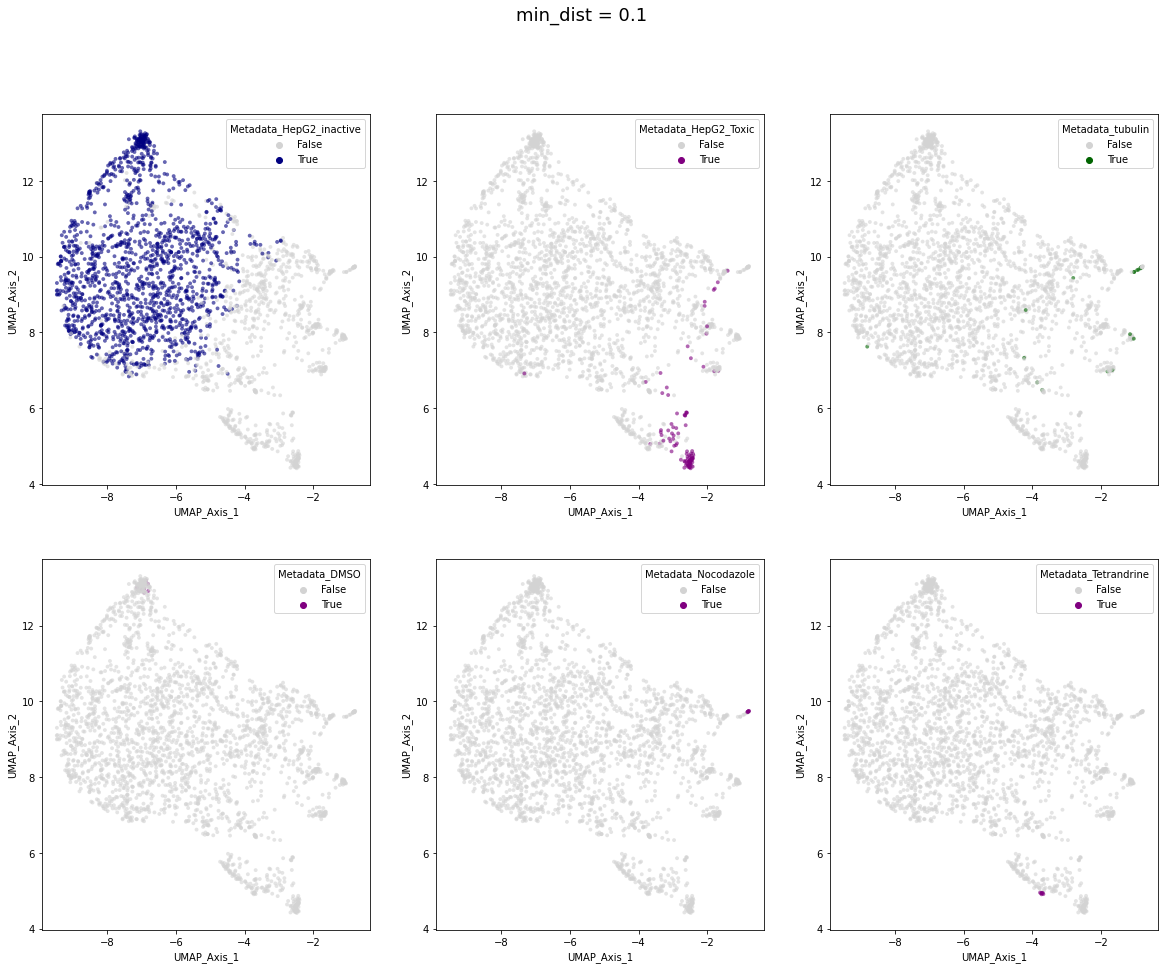

In [27]:
filename_HepG2_UMAP = figure_path + str(date.today()) + "_FMP_HepG2_UMAP_2D_VizOnly.pdf"

draw_umap(data = FMP_HepG2_Data,
          features = FMP_HepG2_x,
          metadata = FMP_HepG2_Meta_Features,
          cell_type='HepG2',
          n_neighbors=30,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_HepG2_UMAP)

# UMAP Cell count senescence


In [28]:
HepG2_Norm_Reduced_Median_annot2.columns.tolist()

['Metadata_EOS',
 'Metadata_Plate',
 'Metadata_Concentration',
 'Metadata_Partner',
 'Nuc_AreaShape_BoundingBoxMaximum_Y',
 'Nuc_AreaShape_Compactness',
 'Nuc_AreaShape_Eccentricity',
 'Nuc_AreaShape_Extent',
 'Nuc_AreaShape_MaxFeretDiameter',
 'Nuc_AreaShape_Orientation',
 'Nuc_AreaShape_Solidity',
 'Nuc_AreaShape_Zernike_0_0',
 'Nuc_AreaShape_Zernike_1_1',
 'Nuc_AreaShape_Zernike_2_2',
 'Nuc_AreaShape_Zernike_3_1',
 'Nuc_AreaShape_Zernike_4_0',
 'Nuc_AreaShape_Zernike_4_2',
 'Nuc_AreaShape_Zernike_4_4',
 'Nuc_AreaShape_Zernike_5_1',
 'Nuc_AreaShape_Zernike_5_3',
 'Nuc_AreaShape_Zernike_5_5',
 'Nuc_AreaShape_Zernike_6_0',
 'Nuc_AreaShape_Zernike_6_2',
 'Nuc_AreaShape_Zernike_6_4',
 'Nuc_AreaShape_Zernike_6_6',
 'Nuc_AreaShape_Zernike_7_1',
 'Nuc_AreaShape_Zernike_7_3',
 'Nuc_AreaShape_Zernike_7_5',
 'Nuc_AreaShape_Zernike_7_7',
 'Nuc_AreaShape_Zernike_8_4',
 'Nuc_AreaShape_Zernike_8_6',
 'Nuc_AreaShape_Zernike_8_8',
 'Nuc_AreaShape_Zernike_9_1',
 'Nuc_AreaShape_Zernike_9_3',
 'Nuc_Are

In [29]:
# Visualization on UMAP space on how different parameters are related. 

# Nuc_Intensity_MeanIntensity_DNA
# Cells_AreaShape_Area
# Metadata_Object_Count
data_HepG2_Norm.columns.tolist()

['Metadata_EOS',
 'Metadata_Object_Count',
 'Metadata_Plate',
 'Metadata_Well',
 'Metadata_Partner',
 'Metadata_Batch',
 'Metadata_Concentration',
 'Nuc_AreaShape_Area',
 'Nuc_AreaShape_BoundingBoxArea',
 'Nuc_AreaShape_BoundingBoxMaximum_X',
 'Nuc_AreaShape_BoundingBoxMaximum_Y',
 'Nuc_AreaShape_BoundingBoxMinimum_X',
 'Nuc_AreaShape_BoundingBoxMinimum_Y',
 'Nuc_AreaShape_Center_X',
 'Nuc_AreaShape_Center_Y',
 'Nuc_AreaShape_Compactness',
 'Nuc_AreaShape_Eccentricity',
 'Nuc_AreaShape_EquivalentDiameter',
 'Nuc_AreaShape_EulerNumber',
 'Nuc_AreaShape_Extent',
 'Nuc_AreaShape_FormFactor',
 'Nuc_AreaShape_MajorAxisLength',
 'Nuc_AreaShape_MaxFeretDiameter',
 'Nuc_AreaShape_MaximumRadius',
 'Nuc_AreaShape_MeanRadius',
 'Nuc_AreaShape_MedianRadius',
 'Nuc_AreaShape_MinFeretDiameter',
 'Nuc_AreaShape_MinorAxisLength',
 'Nuc_AreaShape_Orientation',
 'Nuc_AreaShape_Perimeter',
 'Nuc_AreaShape_Solidity',
 'Nuc_AreaShape_Zernike_0_0',
 'Nuc_AreaShape_Zernike_1_1',
 'Nuc_AreaShape_Zernike_2_0',

In [30]:
## gets feature vector
Features_HepG2_Norm = UTIL.get_feature_vector(data_HepG2_Norm)
Features_HepG2_Norm.append("Metadata_Object_Count") # include object count to compute median

In [31]:
# compute median of HepG2
Features_HepG2_Norm_Median = pycytominer.consensus(
        profiles = data_HepG2_Norm, # A file or pandas DataFrame of profile data
        replicate_columns = ["Metadata_EOS", "Metadata_Plate", "Metadata_Concentration", "Metadata_Partner"], # Metadata columns indicating which replicates to collapse, defaults to [“Metadata_Plate”, “Metadata_Well”]
        operation = "median", # (str) – The method used to form consensus profiles, defaults to “median”
        features = Features_HepG2_Norm, # (str, list) – The features to collapse, defaults to “infer”
)

In [32]:
Features_HepG2_Norm_Median.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_Area,Nuc_AreaShape_BoundingBoxArea,Nuc_AreaShape_BoundingBoxMaximum_X,Nuc_AreaShape_BoundingBoxMaximum_Y,Nuc_AreaShape_BoundingBoxMinimum_X,Nuc_AreaShape_BoundingBoxMinimum_Y,...,Cyto_Texture_Variance_Mito_10_03_256,Cyto_Texture_Variance_Mito_3_00_256,Cyto_Texture_Variance_Mito_3_01_256,Cyto_Texture_Variance_Mito_3_02_256,Cyto_Texture_Variance_Mito_3_03_256,Cyto_Texture_Variance_Mito_5_00_256,Cyto_Texture_Variance_Mito_5_01_256,Cyto_Texture_Variance_Mito_5_02_256,Cyto_Texture_Variance_Mito_5_03_256,Metadata_Object_Count
0,DMSO,B1001,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,925.5
1,DMSO,B1002,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,3.495468e-16,5.993470e-16,6.889698e-16,0.000000e+00,0.0,0.000000e+00,929.0
2,DMSO,B1003,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,4.492934e-16,0.000000e+00,0.0,0.000000e+00,895.5
3,DMSO,B1004,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.998538e-16,0.0,0.000000e+00,914.5
4,DMSO,B1005,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.094591e-16,0.0,0.000000e+00,-4.492934e-16,5.499073e-16,0.000000e+00,0.0,-3.998538e-16,937.0


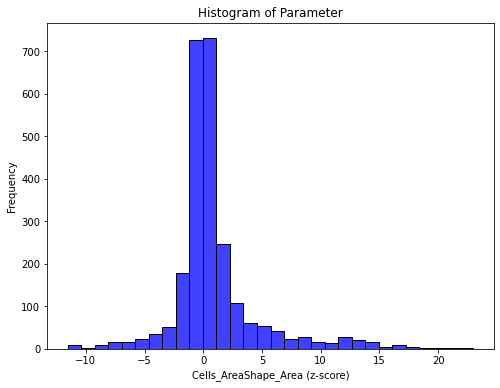

In [33]:
plt.figure(figsize=(8, 6))
sns.histplot(Features_HepG2_Norm_Median["Cells_AreaShape_Area"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Cells_AreaShape_Area (z-score)")
plt.ylabel("Frequency")
plt.show()

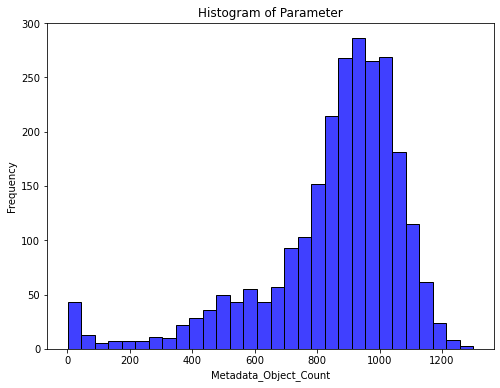

In [34]:
# 1. Histogram
plt.figure(figsize=(8, 6))
sns.histplot(Features_HepG2_Norm_Median["Metadata_Object_Count"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Metadata_Object_Count")
plt.ylabel("Frequency")
plt.show()

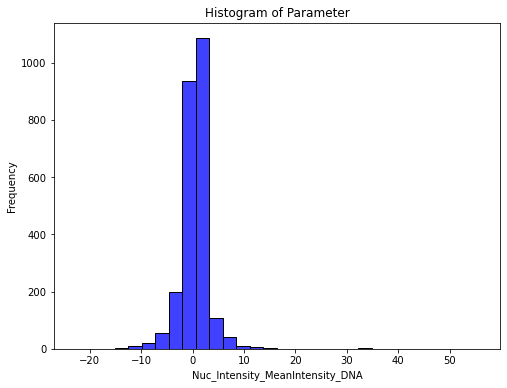

In [35]:
# 1. Histogram
plt.figure(figsize=(8, 6))
sns.histplot(Features_HepG2_Norm_Median["Nuc_Intensity_MeanIntensity_DNA"], bins=30, kde=False, color='blue')
plt.title("Histogram of Parameter")
plt.xlabel("Nuc_Intensity_MeanIntensity_DNA")
plt.ylabel("Frequency")
plt.show()

In [36]:
# Threshold for senescence related features
## Intensity nuc <2 z-score
## Cell area >2 z-score
Features_HepG2_Norm_Median["Nuc_Intensity_low"] = Features_HepG2_Norm_Median["Nuc_Intensity_MeanIntensity_DNA"] < -5
Features_HepG2_Norm_Median["Cells_AreaShape_high"] = Features_HepG2_Norm_Median["Cells_AreaShape_Area"] > 5

In [37]:
data_HepG2_senescence = Features_HepG2_Norm_Median[['Metadata_EOS',
                                        'Metadata_Object_Count',
                                        'Metadata_Plate',
                                        'Metadata_Partner',
                                        'Metadata_Concentration',
                                        'Nuc_Intensity_low', 
                                        'Cells_AreaShape_high']].copy()

In [38]:
data_HepG2_senescence['Sensescence_params'] = data_HepG2_senescence['Nuc_Intensity_low'] & data_HepG2_senescence['Cells_AreaShape_high']

In [39]:
# cell number bin
# Define the fixed bin edges with a width of 200
# bins = [0, 200, 400, 600, 800, 1000, 1200, 1400]
bins = [0, 300, 600, 900, 1300]

# Define the labels for each bin (1-7)
# bin_labels = [1, 2, 3, 4, 5, 6, 7]
bin_labels = [1, 2, 3, 4]

# Create the new column 'bin' based on the defined bins and labels
data_HepG2_senescence['cell_bin'] = pd.cut(data_HepG2_senescence["Metadata_Object_Count"], bins=bins, labels=bin_labels, right=True)

In [40]:
FMP_HepG2_merged = pd.merge(FMP_HepG2_Data, data_HepG2_senescence, on=['Metadata_EOS',
                                                                'Metadata_Plate',
                                                                'Metadata_Partner',
                                                                'Metadata_Concentration'])

In [41]:
FMP_HepG2_merged.head()

,Metadata_EOS,Metadata_Plate,Metadata_Concentration,Metadata_Partner,Nuc_AreaShape_BoundingBoxMaximum_Y,Nuc_AreaShape_Compactness,Nuc_AreaShape_Eccentricity,Nuc_AreaShape_Extent,Nuc_AreaShape_MaxFeretDiameter,Nuc_AreaShape_Orientation,...,Metadata_HepG2_Toxic,Metadata_HepG2_inactive,Metadata_Nocodazole,Metadata_Tetrandrine,Metadata_DMSO,Metadata_Object_Count,Nuc_Intensity_low,Cells_AreaShape_high,Sensescence_params,cell_bin
0,DMSO,B1001,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,925.5,False,False,False,4
1,DMSO,B1002,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,929.0,False,False,False,4
2,DMSO,B1003,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,895.5,False,False,False,3
3,DMSO,B1004,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,914.5,False,False,False,4
4,DMSO,B1005,0,Bioactives,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,937.0,False,False,False,4


# Senescence UMAP

In [42]:
# SN-38, PALBOCICLIB, CAMPTOTHECIN, Ciclopirox ethanolamine, RGB-286638, FLUDARABINE
senescence_compounds = ["SN-38", "PALBOCICLIB", "CAMPTOTHECIN", "CICLOPIROX", "RGB-286638", "FLUDARABINE"]

In [43]:
senescence_compounds_EOS = FMP_HepG2_merged[FMP_HepG2_merged["Metadata_name"].isin(senescence_compounds)]["Metadata_EOS"].unique()

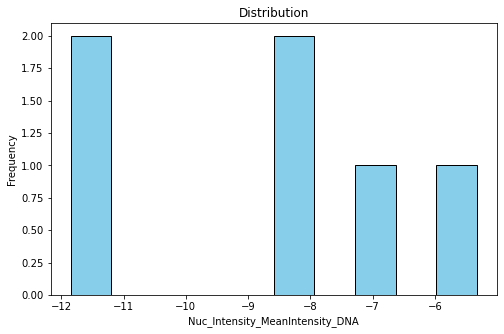

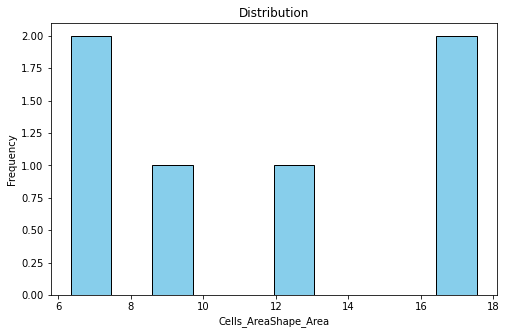

In [44]:
#TODO: identify EOS number of senescence compounds
senescence_features_median = Features_HepG2_Norm_Median[Features_HepG2_Norm_Median["Metadata_EOS"].isin(senescence_compounds_EOS)]

plt.figure(figsize=(8, 5))
plt.hist(senescence_features_median['Nuc_Intensity_MeanIntensity_DNA'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution')
plt.xlabel('Nuc_Intensity_MeanIntensity_DNA')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(senescence_features_median['Cells_AreaShape_Area'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution')
plt.xlabel('Cells_AreaShape_Area')
plt.ylabel('Frequency')
plt.show()

In [45]:
# colors = sns.color_palette("Set2", 7)
colors = sns.color_palette("Set2", 4)

In [46]:
def draw_umap(data,
              features,
              metadata,
              cell_type, 
              n_neighbors=15, 
              min_dist=0.1, 
              n_components=2, 
              metric='euclidean',
              title='',
              filename = ''):
    
    # function is a UMAP
    axis_1 = "UMAP_Axis_1"
    axis_2 = "UMAP_Axis_2"
    
    # plot params
    marker_color = ["lightgray", "purple"]
    marker_edgecolor = "none"
    marker_size = 15
    marker_alpha = 0.6
    
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    u = fit.fit_transform(features)

    u_dataframe = pd.DataFrame(data = u,
                               columns = [axis_1, 
                                          axis_2])

    # Get EOS annotation back
    u_dataframe_annot = pd.merge(data.loc[:, metadata], 
                                  u_dataframe, 
                                  left_index = True, 
                                  right_index = True)
    
    ### 
    filename_umap = output_path + str(date.today()) + "_FMP_HepG2_UMAP.csv"
    u_dataframe_annot.to_csv(filename_umap, index = False)
    
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))
    fig.suptitle(title, fontsize=18)

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        edgecolor = marker_edgecolor,
        hue = 'cell_bin',
        palette = colors,
        s = marker_size,
        alpha = marker_alpha,
        ax=axs[0]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        hue = 'Sensescence_params',
        palette = ["lightgray", "darkgreen"],
        edgecolor = marker_edgecolor,
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[1]
    )

    sns.scatterplot(
        data = u_dataframe_annot,
        x=axis_1,
        y=axis_2,
        edgecolor = marker_edgecolor,
        color = ["lightgray"],
        s = marker_size,
        alpha = marker_alpha,
        zorder=1,
        ax=axs[2]
    )


        # Add labels for specific points based on matching IDs
    for i, row in u_dataframe_annot.iterrows():
        if row["Metadata_name"] in senescence_compounds:  # Check if the ID matches the target list

            plt.scatter(row["UMAP_Axis_1"], 
                        row["UMAP_Axis_2"], 
                        color = 'red',
                        s=marker_size, 
                        alpha = 1,
                        zorder=3)

            plt.annotate(
                row["Metadata_name"],  # The label text
                (row["UMAP_Axis_1"], row["UMAP_Axis_2"]),  # The (x, y) coordinates
                textcoords="offset points",  # Positioning the label
                xytext=(5, 5),  # Offset from the point
                ha="center",  # Horizontal alignment
                fontsize=6,  # Font size
                color="red"  # Text color
             )
       
    plt.savefig(filename)

In [47]:
# Data without metadata columns
FMP_HepG2_merged_reset = FMP_HepG2_merged.reset_index(drop = True)
FMP_HepG2_merged_reset_Features = UTIL.get_feature_vector(FMP_HepG2_merged_reset)
FMP_HepG2_merged_reset_Meta_Features = list(set(FMP_HepG2_merged_reset.columns) - set(FMP_HepG2_merged_reset_Features))
    
FMP_HepG2_merged_reset_x = FMP_HepG2_merged_reset.loc[:,FMP_HepG2_merged_reset_Features]

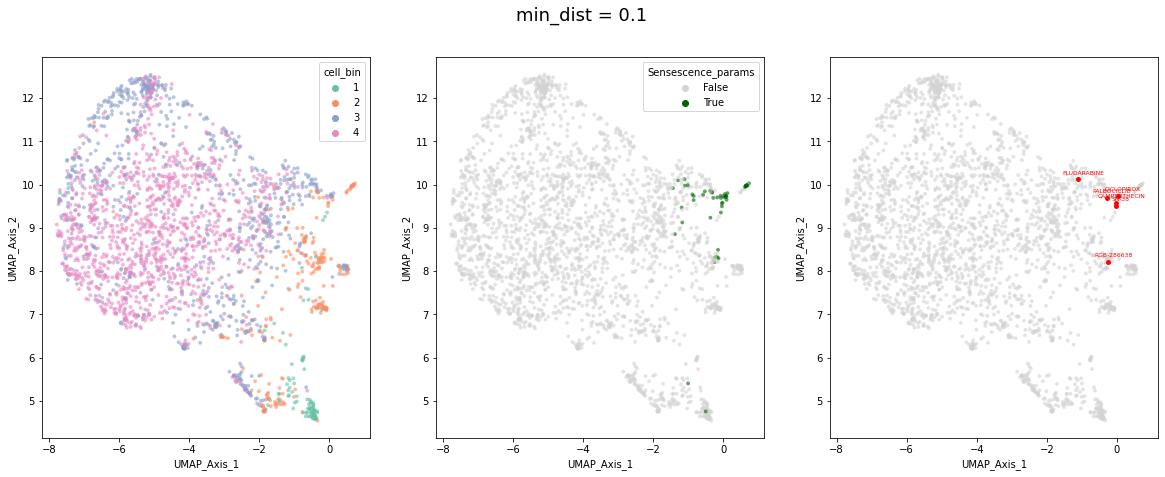

In [48]:
filename_HepG2_UMAP = figure_path + str(date.today()) + "_FMP_HepG2_UMAP_2D_Senescence.pdf"

draw_umap(data = FMP_HepG2_merged,
          features = FMP_HepG2_merged_reset_x,
          metadata = FMP_HepG2_merged_reset_Meta_Features,
          cell_type='HepG2',
          n_neighbors=30,
          min_dist=0.1,
          title='min_dist = {}'.format(0.1),
          filename = filename_HepG2_UMAP)